In [16]:
!pip install lime; 
!pip install optuna;
!pip install lightgbm;
!pip install xgboost==2.1.4;
!pip install seaborn
# !pip install shap

  Using cached lime-0.2.0.1-py3-none-any.whl
  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached sqlalchemy-2.0.49-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
  Using cached greenlet-3.5.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (3.7 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
Using cached sqlalchemy-2.0.49-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (3.4 MB)
Using cached greenlet-3.5.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (611 kB)
Using cached mako-1.3.12-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [optuna]2m4/5 [optuna]]my]
  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17

In [17]:
import numpy as np
import pandas as pd
import torch
import shap
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset

import lime
import xgboost
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
from lime.lime_tabular import LimeTabularExplainer
 
import warnings
warnings.filterwarnings('ignore')


np.random.seed(1)

In [18]:
!curl -o data/clients.zip https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip
!unzip -o data/clients.zip -d data
!rm data/clients.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 5409k    0 5409k    0     0  5133k      0 --:--:--  0:00:01 --:--:-- 5137k
Archive:  data/clients.zip
 extracting: data/default of credit card clients.xls  


In [19]:
# Load the data
data = pd.read_excel(
    "data/default of credit card clients.xls",
    header=1,
)
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


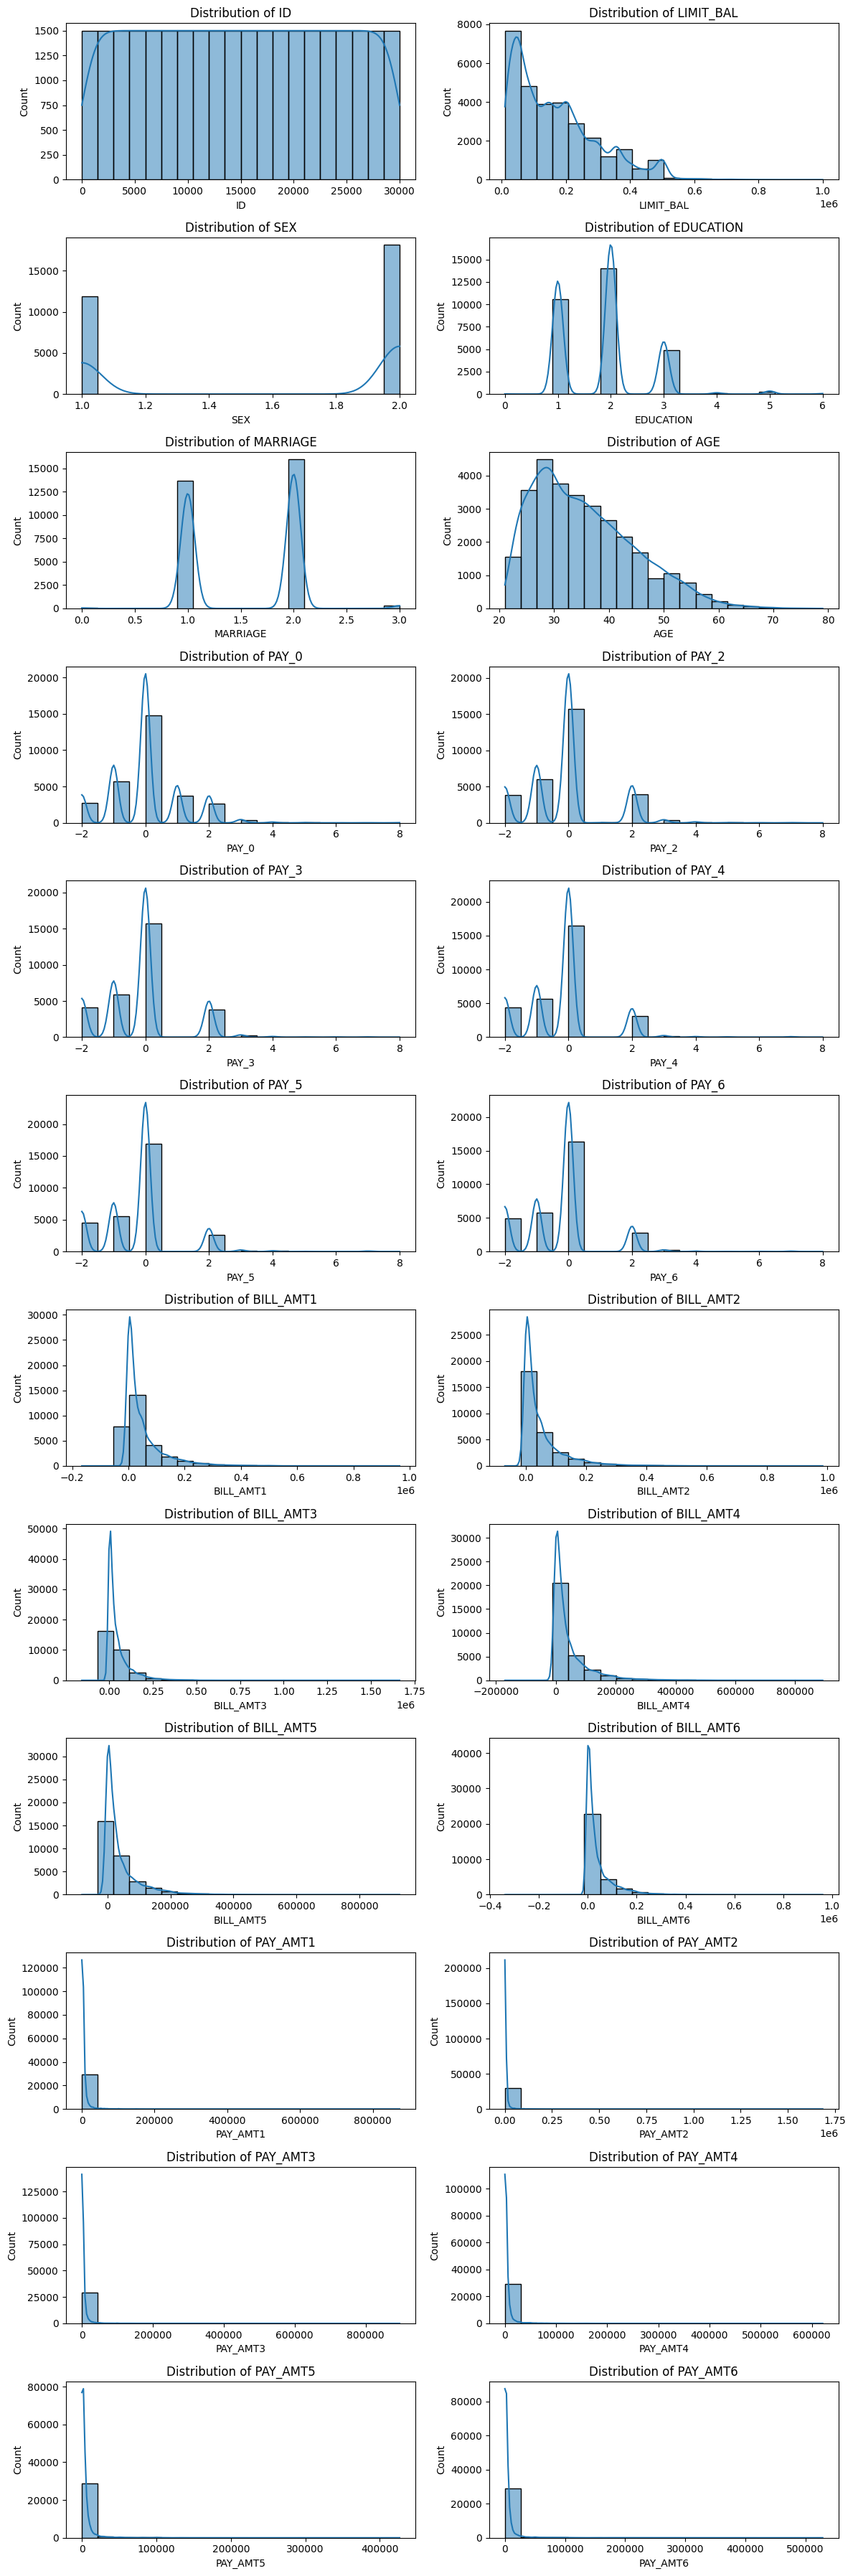

In [20]:
df = pd.DataFrame(data)
target = 'default payment next month'

features = df.select_dtypes(include = np.number).columns.drop(target, errors = 'ignore')

n_features = len(features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*3))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde = True, ax=axes[i], bins = 20)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

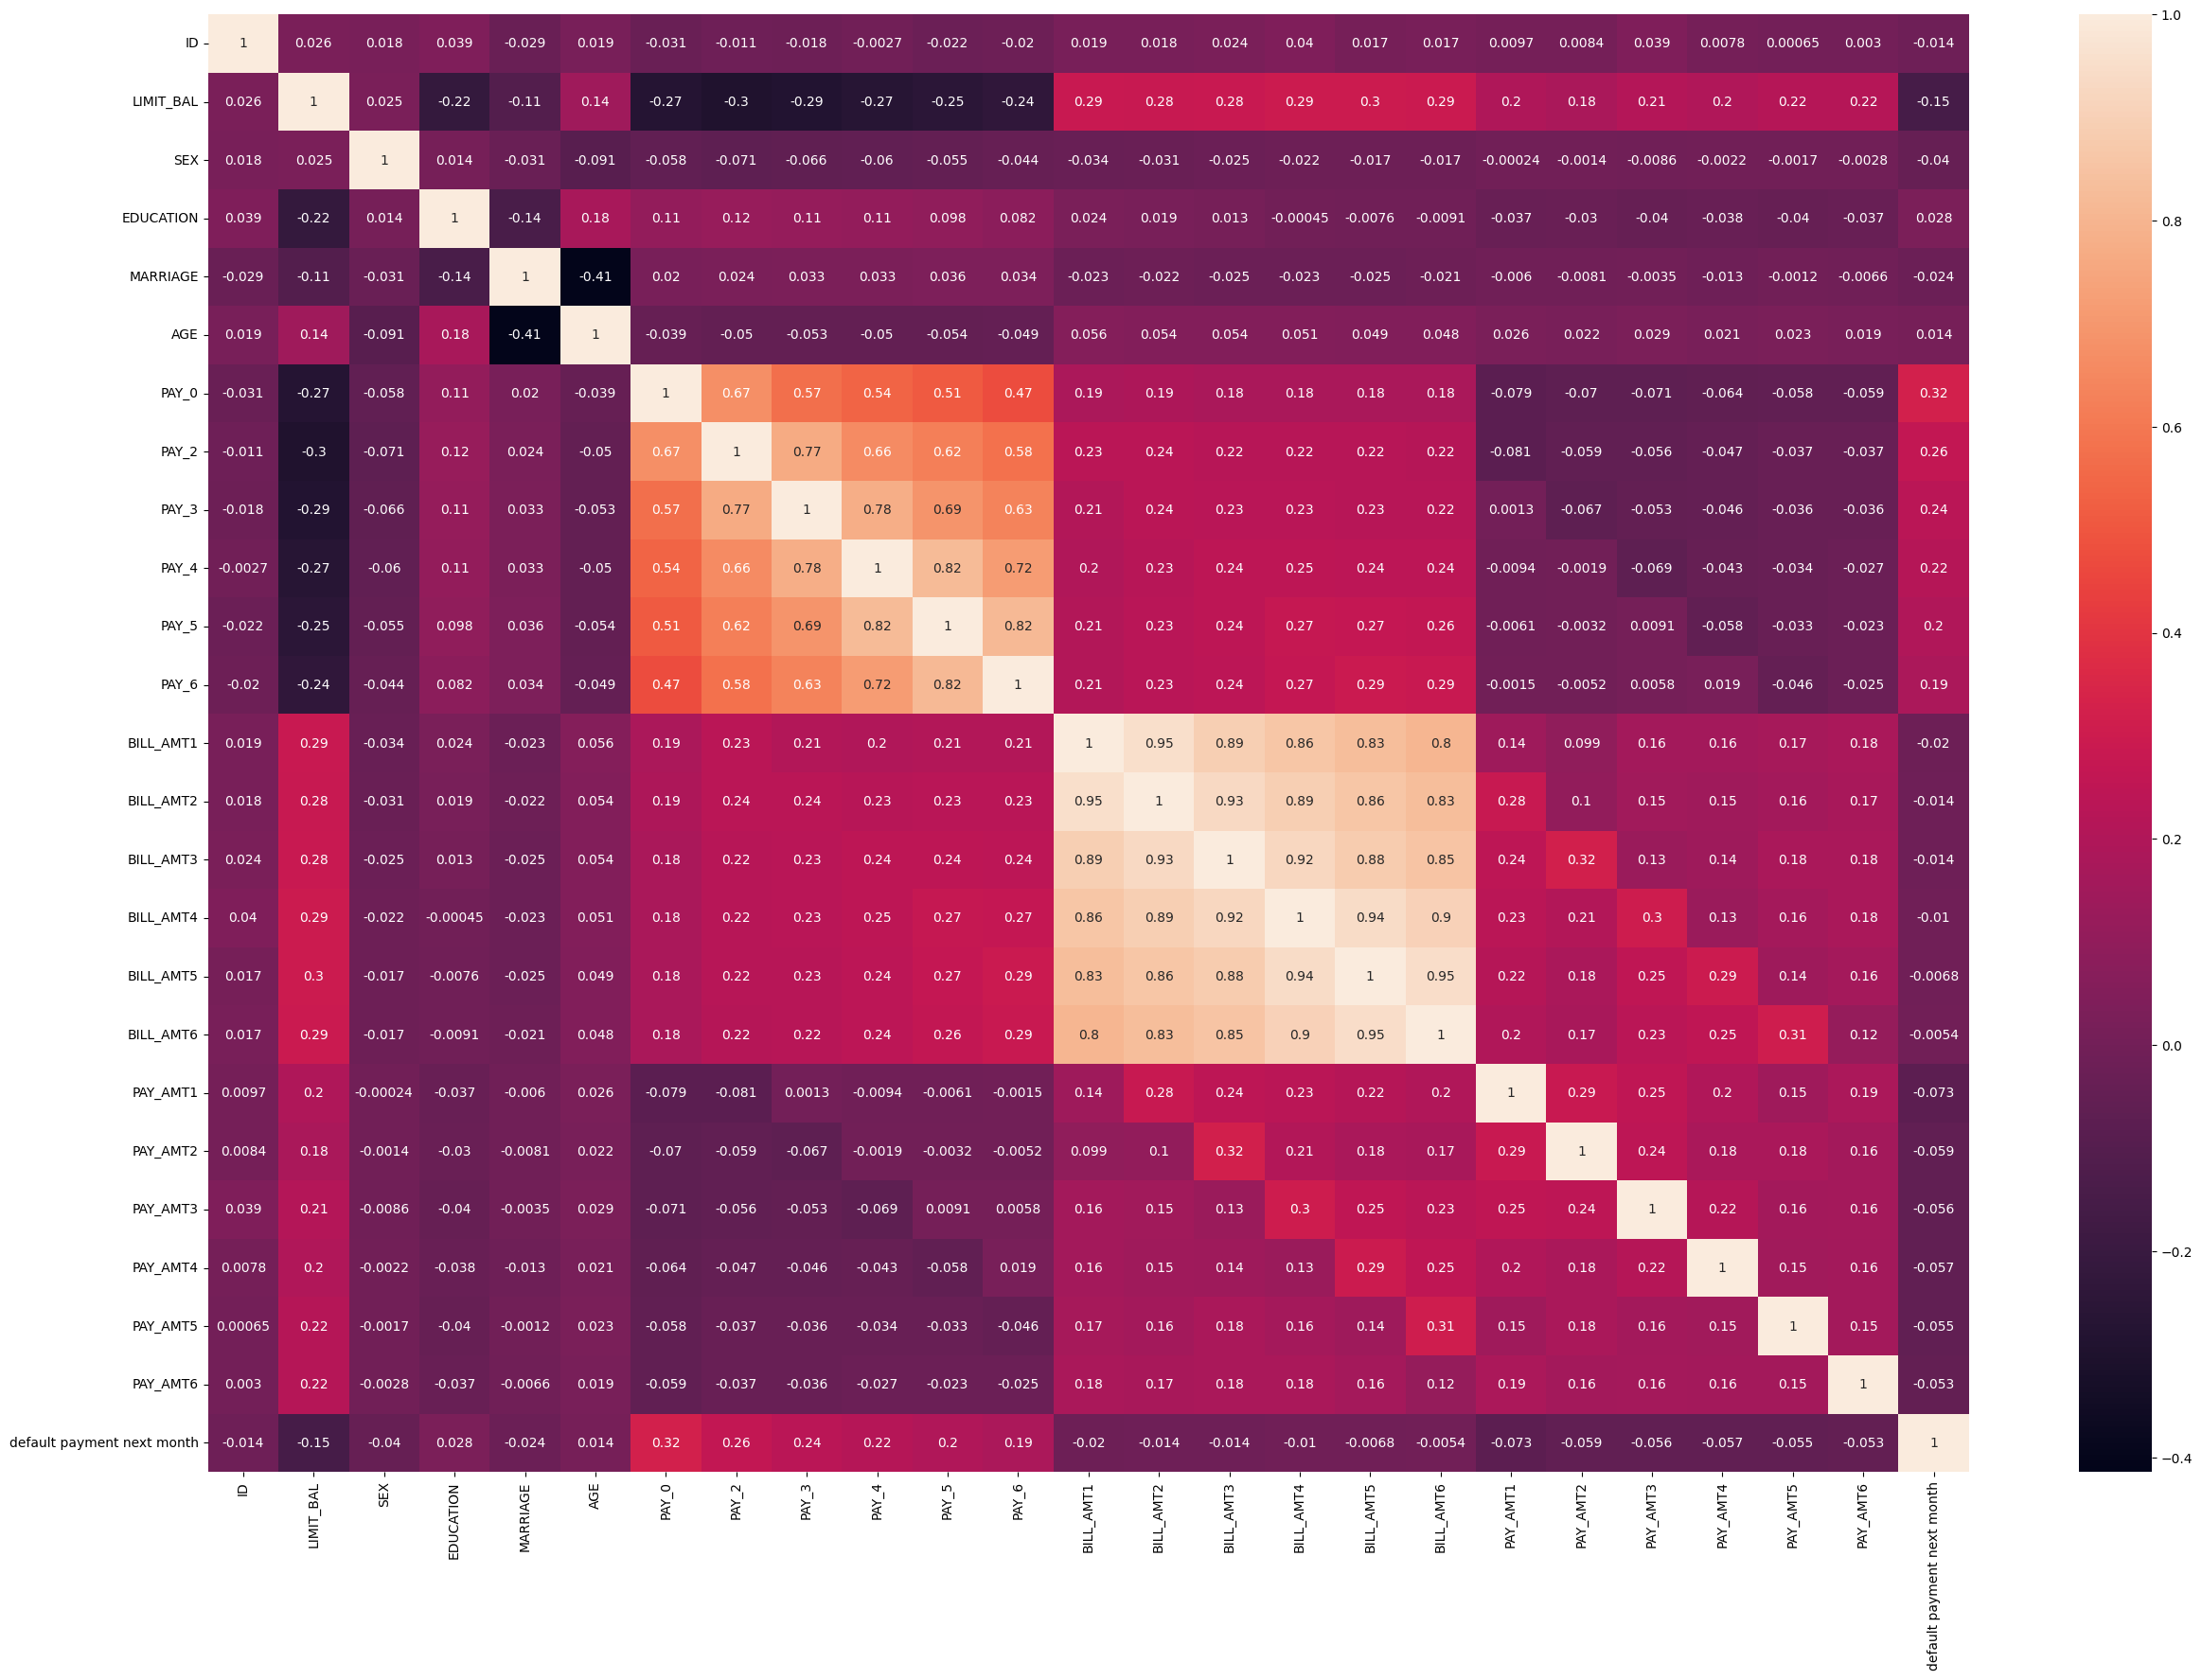

In [ ]:
plt.subplots(figsize=(30,20))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [23]:
X = data.drop(['default payment next month'], axis = 1)
y = data['default payment next month']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


--- Plotting Feature Importances ---


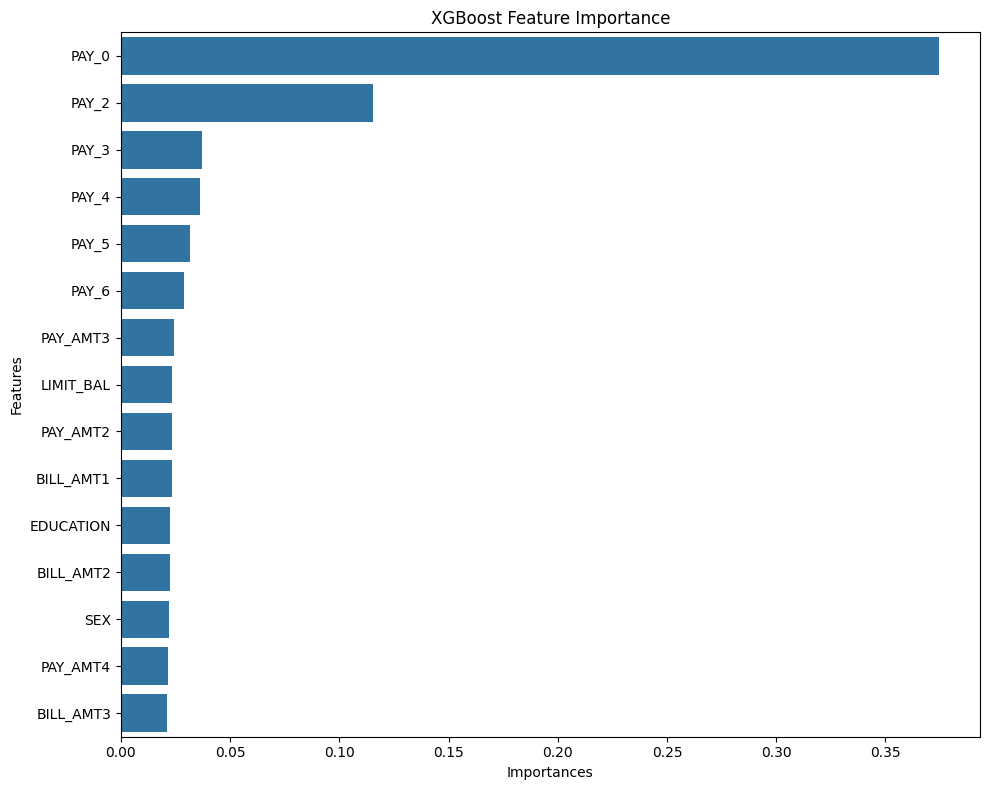

In [24]:
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
X_df = pd.DataFrame(X, columns=feature_names)

base_model = XGBClassifier(n_estimators = 100,random_state = 42, base_score=0.5)

base_model.fit(X_train, y_train)
xgb_importances = base_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Features' : X_train.columns,
    'Importances' : xgb_importances
})

feature_importance_df = feature_importance_df.sort_values(by = 'Importances', ascending = False)

print("\n--- Plotting Feature Importances ---")
plt.figure(figsize=(10, 8))
sns.barplot(x='Importances', y = 'Features', data = feature_importance_df.head(15))
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [25]:
y_pred = base_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")


Test Accuracy: 0.8180


In [26]:
X_test

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
2308,2309,30000,1,2,2,25,0,0,0,0,...,11581,12580,13716,14828,1500,2000,1500,1500,1500,2000
22404,22405,150000,2,1,2,26,0,0,0,0,...,116684,101581,77741,77264,4486,4235,3161,2647,2669,2669
23397,23398,70000,2,3,1,32,0,0,0,0,...,68530,69753,70111,70212,2431,3112,3000,2438,2500,2554
25058,25059,130000,1,3,2,49,0,0,0,0,...,16172,16898,11236,6944,1610,1808,7014,27,7011,4408
2664,2665,50000,2,2,2,36,0,0,0,0,...,42361,19574,20295,19439,2000,1500,1000,1800,0,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,2211,360000,2,1,2,27,1,-2,-1,-1,...,830,0,1271,179,0,830,0,1271,179,1970
14144,14145,500000,2,1,2,28,2,0,0,2,...,111690,78070,78376,80912,6000,13151,0,3000,5000,10000
23108,23109,60000,2,1,1,28,0,0,0,0,...,48696,50385,52045,52661,2100,2500,2500,2500,1600,1500
25703,25704,20000,2,1,2,29,1,-1,-1,-1,...,3967,1364,600,0,2494,3967,1370,600,0,0


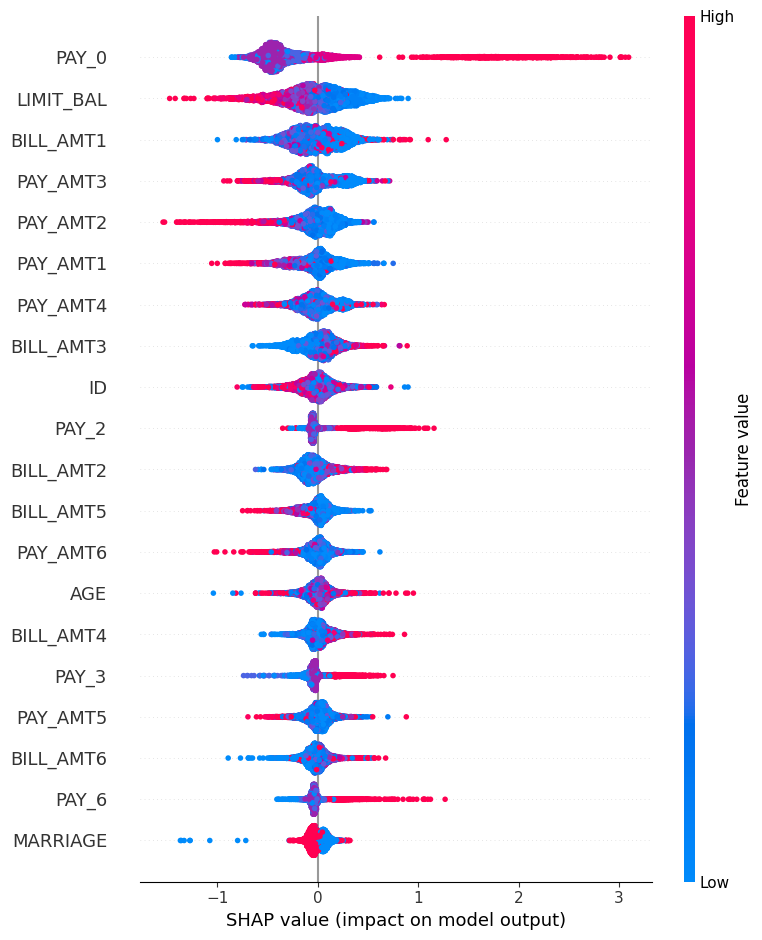

In [27]:
shap_explainer = shap.TreeExplainer(base_model)

shap_values = shap_explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)